In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv(r"C:\Users\yashr\Downloads\train.csv.zip")
df.head()

,id,qid1,qid2,question1,question2,is_duplicate
0,0,1,2,What is the step by step guide to invest in sh...,What is the step by step guide to invest in sh...,0
1,1,3,4,What is the story of Kohinoor (Koh-i-Noor) Dia...,What would happen if the Indian government sto...,0
2,2,5,6,How can I increase the speed of my internet co...,How can Internet speed be increased by hacking...,0
3,3,7,8,Why am I mentally very lonely? How can I solve...,Find the remainder when [math]23^{24}[/math] i...,0
4,4,9,10,"Which one dissolve in water quikly sugar, salt...",Which fish would survive in salt water?,0


In [3]:
df.isnull().sum()

id              0
qid1            0
qid2            0
question1       1
question2       2
is_duplicate    0
dtype: int64

In [70]:
df['question1'].head(1)

0    What is the step by step guide to invest in sh...
Name: question1, dtype: str

In [4]:
new_df = df.sample(40000)

In [5]:
new_df.isnull().sum()

id              0
qid1            0
qid2            0
question1       0
question2       0
is_duplicate    0
dtype: int64

In [6]:
new_df.duplicated().sum()

np.int64(0)

is_duplicate
0    25235
1    14765
Name: count, dtype: int64
is_duplicate
0    63.0875
1    36.9125
Name: count, dtype: float64


<Axes: xlabel='is_duplicate'>

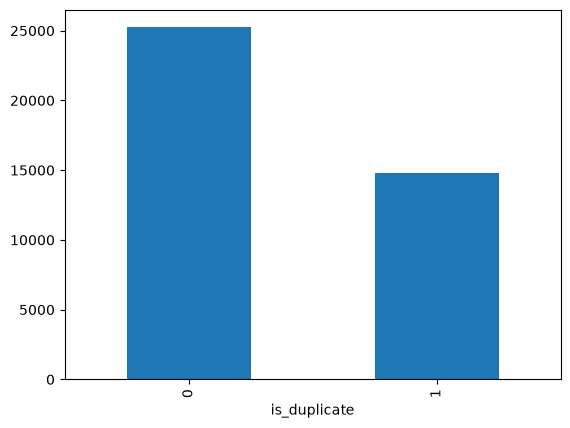

In [7]:
print(new_df['is_duplicate'].value_counts())
print((new_df['is_duplicate'].value_counts()/new_df['is_duplicate'].count())*100)
new_df['is_duplicate'].value_counts().plot(kind='bar')

In [8]:
qid = pd.Series(new_df['qid1'].tolist() + new_df['qid2'].tolist())
print('Number of unique questions',np.unique(qid).shape[0])
x = qid.value_counts()>1
print('Number of questions getting repeated',x[x].shape[0])

Number of unique questions 72250
Number of questions getting repeated 5372


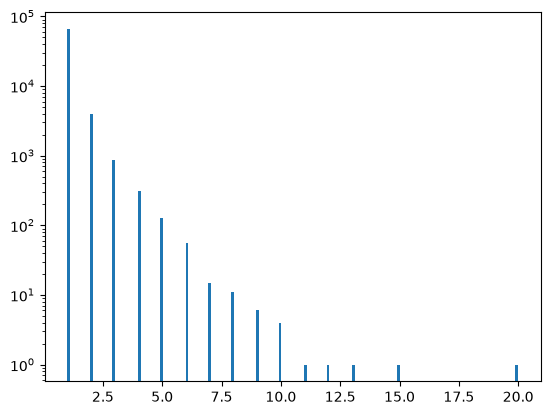

In [9]:
plt.hist(qid.value_counts().values,bins=160)
plt.yscale('log')
plt.show()

In [10]:
# q1 and q2 len count 
new_df['q1_len'] = new_df['question1'].str.len()
new_df['q2_len'] = new_df['question2'].str.len()

In [11]:
new_df.head()

,id,qid1,qid2,question1,question2,is_duplicate,q1_len,q2_len
303619,303619,133245,104455,Is there an advantage to PC gaming vs console ...,Is PC gaming better than console gaming?,1,112,40
57315,57315,100732,100733,Do women enjoy it when they give a man a blowjob?,Fellatio: Do women like to give blow jobs?,1,49,42
174032,174032,268318,268319,What stocks will do well if Trump wins?,Do Trump hard core supporters believe that pol...,0,39,91
146390,146390,98155,21232,How do I get rid off from porn addiction?,How can I stop my porn addiction?,1,41,33
32510,32510,59841,59842,Why do women put their feet on the dashboard?,How long are your feet?,0,45,23


In [12]:
# word  occured in que 1 & que 2
new_df['q1_num_words'] = new_df['question1'].apply(lambda row: len(row.split(" ")))
new_df['q2_num_words'] = new_df['question2'].apply(lambda row: len(row.split(" ")))
new_df.head()

,id,qid1,qid2,question1,question2,is_duplicate,q1_len,q2_len,q1_num_words,q2_num_words
303619,303619,133245,104455,Is there an advantage to PC gaming vs console ...,Is PC gaming better than console gaming?,1,112,40,20,7
57315,57315,100732,100733,Do women enjoy it when they give a man a blowjob?,Fellatio: Do women like to give blow jobs?,1,49,42,11,8
174032,174032,268318,268319,What stocks will do well if Trump wins?,Do Trump hard core supporters believe that pol...,0,39,91,8,16
146390,146390,98155,21232,How do I get rid off from porn addiction?,How can I stop my porn addiction?,1,41,33,9,7
32510,32510,59841,59842,Why do women put their feet on the dashboard?,How long are your feet?,0,45,23,9,5


In [13]:
#common word in both question
def common_words(row):
    w1 = set(map(lambda word : word.lower().strip(),row['question1'].split(" ")))
    w2 = set(map(lambda word : word.lower().strip(),row['question2'].split(" ")))
    return len(w1 & w2)

In [14]:
new_df['word_common'] = new_df.apply(common_words,axis=1)
new_df.head()

,id,qid1,qid2,question1,question2,is_duplicate,q1_len,q2_len,q1_num_words,q2_num_words,word_common
303619,303619,133245,104455,Is there an advantage to PC gaming vs console ...,Is PC gaming better than console gaming?,1,112,40,20,7,5
57315,57315,100732,100733,Do women enjoy it when they give a man a blowjob?,Fellatio: Do women like to give blow jobs?,1,49,42,11,8,3
174032,174032,268318,268319,What stocks will do well if Trump wins?,Do Trump hard core supporters believe that pol...,0,39,91,8,16,2
146390,146390,98155,21232,How do I get rid off from porn addiction?,How can I stop my porn addiction?,1,41,33,9,7,4
32510,32510,59841,59842,Why do women put their feet on the dashboard?,How long are your feet?,0,45,23,9,5,0


In [15]:
# total words of both question 
def total_word(row):
    W1 = set(map(lambda word: word.lower().strip(),row['question1'].split(" ")))
    W2 = set(map(lambda word : word.lower().strip(),row['question2'].split(" ")))
    return (len(W1) + len(W2))

In [16]:
new_df['total_word'] = new_df.apply(total_word,axis=1)
new_df.head()

,id,qid1,qid2,question1,question2,is_duplicate,q1_len,q2_len,q1_num_words,q2_num_words,word_common,total_word
303619,303619,133245,104455,Is there an advantage to PC gaming vs console ...,Is PC gaming better than console gaming?,1,112,40,20,7,5,24
57315,57315,100732,100733,Do women enjoy it when they give a man a blowjob?,Fellatio: Do women like to give blow jobs?,1,49,42,11,8,3,18
174032,174032,268318,268319,What stocks will do well if Trump wins?,Do Trump hard core supporters believe that pol...,0,39,91,8,16,2,24
146390,146390,98155,21232,How do I get rid off from porn addiction?,How can I stop my porn addiction?,1,41,33,9,7,4,16
32510,32510,59841,59842,Why do women put their feet on the dashboard?,How long are your feet?,0,45,23,9,5,0,14


In [17]:
# word sharing
new_df['word_share'] = round(new_df['word_common']/new_df['total_word'],2)
new_df.head()

,id,qid1,qid2,question1,question2,is_duplicate,q1_len,q2_len,q1_num_words,q2_num_words,word_common,total_word,word_share
303619,303619,133245,104455,Is there an advantage to PC gaming vs console ...,Is PC gaming better than console gaming?,1,112,40,20,7,5,24,0.21
57315,57315,100732,100733,Do women enjoy it when they give a man a blowjob?,Fellatio: Do women like to give blow jobs?,1,49,42,11,8,3,18,0.17
174032,174032,268318,268319,What stocks will do well if Trump wins?,Do Trump hard core supporters believe that pol...,0,39,91,8,16,2,24,0.08
146390,146390,98155,21232,How do I get rid off from porn addiction?,How can I stop my porn addiction?,1,41,33,9,7,4,16,0.25
32510,32510,59841,59842,Why do women put their feet on the dashboard?,How long are your feet?,0,45,23,9,5,0,14,0.00


minimum character 1
maximum character 430
average character 59.59555


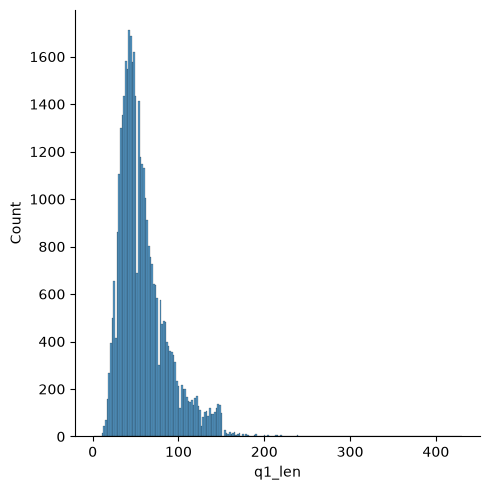

In [18]:
#outlier checking 
sns.displot(new_df['q1_len'])
print('minimum character',new_df['q1_len'].min())
print('maximum character',new_df['q1_len'].max())
print('average character',new_df['q1_len'].mean())

minimum character 5
maximum character 1151
average character 60.127225


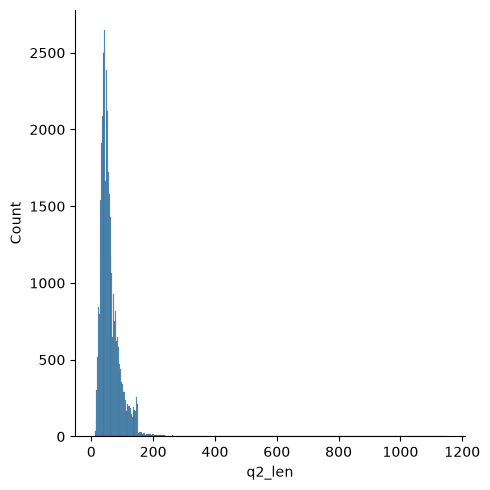

In [19]:
sns.displot(new_df['q2_len'])
print('minimum character',new_df['q2_len'].min())
print('maximum character',new_df['q2_len'].max())
print('average character',new_df['q2_len'].mean())

minimum character 1
maximum character 81
average character 10.9472


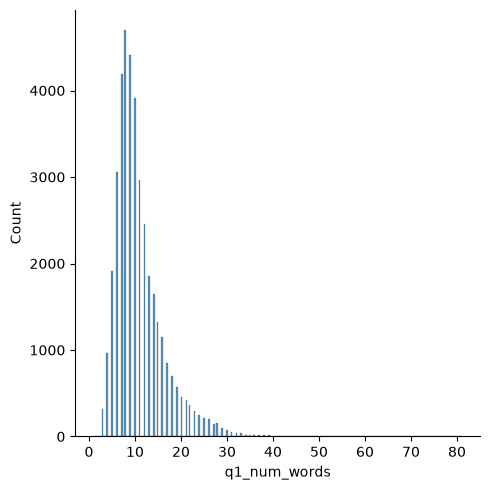

In [20]:
sns.displot(new_df['q1_num_words'])
print('minimum character',new_df['q1_num_words'].min())
print('maximum character',new_df['q1_num_words'].max())
print('average character',new_df['q1_num_words'].mean())

C:\Users\yashr\AppData\Local\Temp\ipykernel_10112\2492214095.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(new_df[new_df['is_duplicate'] == 0]['word_common'],label='non duplicate')
C:\Users\yashr\AppData\Local\Temp\ipykernel_10112\2492214095.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distp

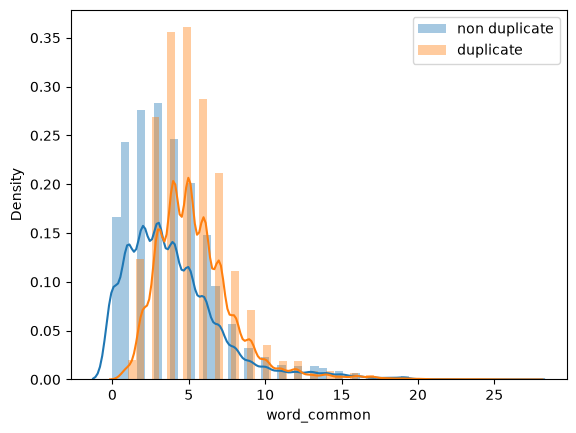

In [21]:
# common words
sns.distplot(new_df[new_df['is_duplicate'] == 0]['word_common'],label='non duplicate')
sns.distplot(new_df[new_df['is_duplicate'] == 1]['word_common'],label='duplicate')
plt.legend()
plt.show()

In [22]:
# outlier removing 
q1 = new_df['q1_len'].quantile(0.25)
q3 = new_df['q1_len'].quantile(0.75)


In [23]:
iqr = q3 - q1

In [24]:
minrange = q1 - (1.5 * iqr)
maxrange = q3 + (1.5*iqr)

In [25]:
minrange , maxrange


(np.float64(-10.5), np.float64(121.5))

In [26]:
new_df = new_df[new_df['q1_len']<=maxrange]

minimum character 1
maximum character 121
average character 55.089754044456136


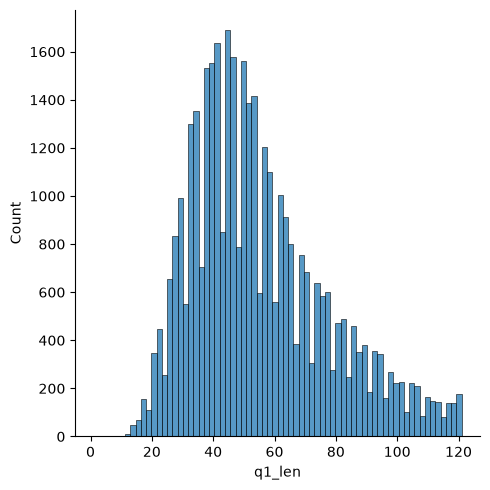

In [27]:
sns.displot(new_df['q1_len'])
print('minimum character',new_df['q1_len'].min())
print('maximum character',new_df['q1_len'].max())
print('average character',new_df['q1_len'].mean())

In [28]:
q1 = new_df['q2_len'].quantile(0.25)
q3 = new_df['q2_len'].quantile(0.75)
iqr = q3 - q1
minrange , maxrange
new_df = new_df[new_df['q2_len']<=maxrange]

minimum character 5
maximum character 121
average character 53.401706569464004


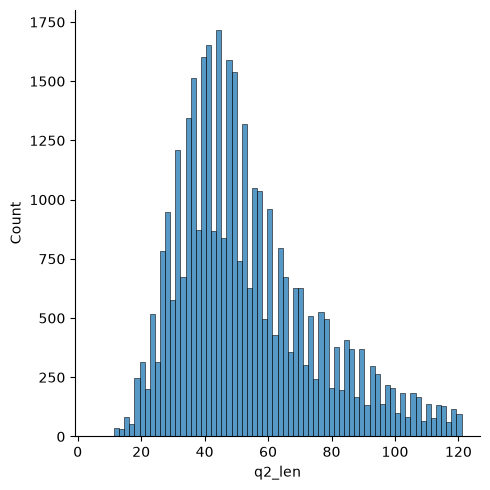

In [29]:
sns.displot(new_df['q2_len'])
print('minimum character',new_df['q2_len'].min())
print('maximum character',new_df['q2_len'].max())
print('average character',new_df['q2_len'].mean())

In [30]:
q1 = new_df['q1_num_words'].quantile(0.25)
q3 = new_df['q1_num_words'].quantile(0.75)
iqr = q3 - q1
minrange , maxrange
new_df = new_df[new_df['q1_num_words']<=maxrange]

minimum character 1
maximum character 28
average character 9.989644602766962


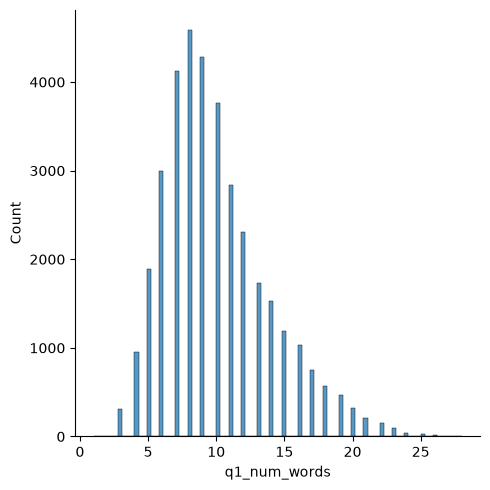

In [31]:
sns.displot(new_df['q1_num_words'])
print('minimum character',new_df['q1_num_words'].min())
print('maximum character',new_df['q1_num_words'].max())
print('average character',new_df['q1_num_words'].mean())

In [32]:
q1 = new_df['q2_num_words'].quantile(0.25)
q3 = new_df['q2_num_words'].quantile(0.75)
iqr = q3 - q1
minrange , maxrange
new_df = new_df[new_df['q2_num_words']<=maxrange]

minimum character 1
maximum character 28
average character 9.962333968464364


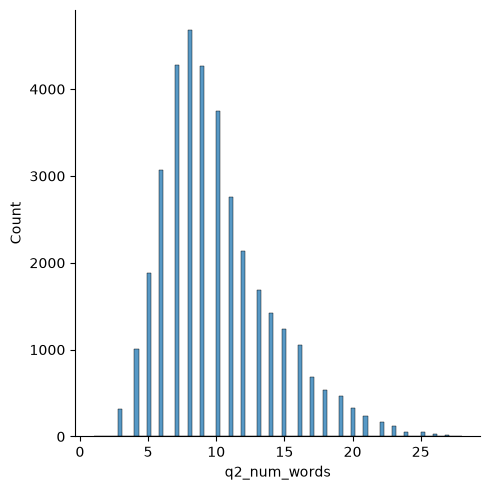

In [33]:
sns.displot(new_df['q2_num_words'])
print('minimum character',new_df['q2_num_words'].min())
print('maximum character',new_df['q2_num_words'].max())
print('average character',new_df['q2_num_words'].mean())

In [34]:
q1 = new_df['word_common'].quantile(0.25)
q3 = new_df['word_common'].quantile(0.75)
iqr = q3 - q1
minrange , maxrange
new_df = new_df[new_df['word_common']<=maxrange]

minimum character 0
maximum character 22
average character 4.374175020020434


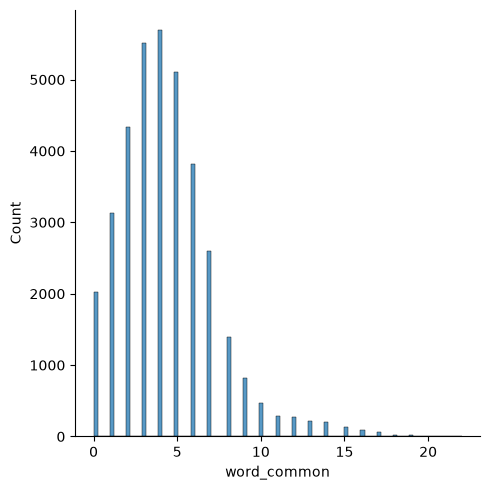

In [35]:

sns.displot(new_df['word_common'])
print('minimum character',new_df['word_common'].min())
print('maximum character',new_df['word_common'].max())
print('average character',new_df['word_common'].mean())


In [36]:
q1 = new_df['total_word'].quantile(0.25)
q3 = new_df['total_word'].quantile(0.75)
iqr = q3 - q1
minrange , maxrange
new_df = new_df[new_df['total_word']<=maxrange]

minimum character 3
maximum character 46
average character 19.32184574600282


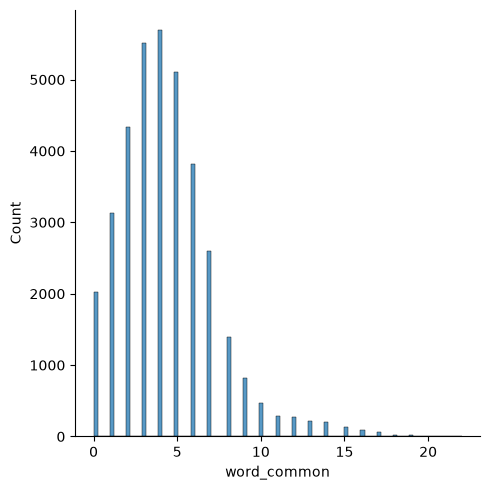

In [37]:
sns.displot(new_df['word_common'])
print('minimum character',new_df['total_word'].min())
print('maximum character',new_df['total_word'].max())
print('average character',new_df['total_word'].mean())


In [38]:
q1 = new_df['word_common'].quantile(0.25)
q3 = new_df['word_common'].quantile(0.75)
iqr = q3 - q1
minrange , maxrange
new_df = new_df[new_df['word_common']<=maxrange]

minimum character 0
maximum character 22
average character 4.374175020020434


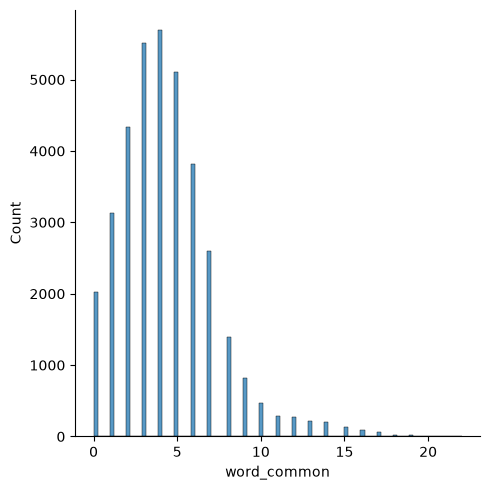

In [39]:
sns.displot(new_df['word_common'])
print('minimum character',new_df['word_common'].min())
print('maximum character',new_df['word_common'].max())
print('average character',new_df['word_common'].mean())


In [40]:
new_df.head()

,id,qid1,qid2,question1,question2,is_duplicate,q1_len,q2_len,q1_num_words,q2_num_words,word_common,total_word,word_share
303619,303619,133245,104455,Is there an advantage to PC gaming vs console ...,Is PC gaming better than console gaming?,1,112,40,20,7,5,24,0.21
57315,57315,100732,100733,Do women enjoy it when they give a man a blowjob?,Fellatio: Do women like to give blow jobs?,1,49,42,11,8,3,18,0.17
174032,174032,268318,268319,What stocks will do well if Trump wins?,Do Trump hard core supporters believe that pol...,0,39,91,8,16,2,24,0.08
146390,146390,98155,21232,How do I get rid off from porn addiction?,How can I stop my porn addiction?,1,41,33,9,7,4,16,0.25
32510,32510,59841,59842,Why do women put their feet on the dashboard?,How long are your feet?,0,45,23,9,5,0,14,0.00


In [41]:
ques_df = new_df[['question1','question2']]
print(ques_df.head())

                                                question1  \
303619  Is there an advantage to PC gaming vs console ...   
57315   Do women enjoy it when they give a man a blowjob?   
174032            What stocks will do well if Trump wins?   
146390          How do I get rid off from porn addiction?   
32510       Why do women put their feet on the dashboard?   

                                                question2  
303619           Is PC gaming better than console gaming?  
57315          Fellatio: Do women like to give blow jobs?  
174032  Do Trump hard core supporters believe that pol...  
146390                  How can I stop my porn addiction?  
32510                             How long are your feet?  


In [42]:
final_df = new_df.drop(columns=['id','qid1','qid2','question1','question2'])

In [43]:
# here we will use tfidf

In [44]:
questions = list(ques_df['question1']) + list(ques_df['question2'])

In [45]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [46]:
tfidf = TfidfVectorizer(
    max_features=3000,
    ngram_range=(1,2)
)

In [47]:
tfidf_matrix = tfidf.fit_transform(questions).toarray()

print("TF-IDF matrix shape:", tfidf_matrix.shape)


TF-IDF matrix shape: (72426, 3000)


In [48]:
q1_arr, q2_arr = np.vsplit(
    tfidf_matrix,
    2
)

print("Question 1 vector shape:", q1_arr.shape)
print("Question 2 vector shape:", q2_arr.shape)



Question 1 vector shape: (36213, 3000)
Question 2 vector shape: (36213, 3000)


In [49]:
temp_df1 = pd.DataFrame(
    q1_arr,
    index=ques_df.index
)

temp_df2 = pd.DataFrame(
    q2_arr,
    index=ques_df.index
)


In [50]:
temp_df = pd.concat(
    [temp_df1, temp_df2],
    axis=1
)

print("TF-IDF feature DataFrame shape:", temp_df.shape)



TF-IDF feature DataFrame shape: (36213, 6000)


In [51]:
final_df = pd.concat(
    [final_df, temp_df],
    axis=1
)

print("Final DataFrame shape:", final_df.shape)
print(final_df.head())

Final DataFrame shape: (36213, 6008)
        is_duplicate  q1_len  q2_len  q1_num_words  q2_num_words  word_common  \
303619             1     112      40            20             7            5   
57315              1      49      42            11             8            3   
174032             0      39      91             8            16            2   
146390             1      41      33             9             7            4   
32510              0      45      23             9             5            0   

        total_word  word_share    0    1  ...  2990  2991  2992  2993  2994  \
303619          24        0.21  0.0  0.0  ...   0.0   0.0   0.0   0.0   0.0   
57315           18        0.17  0.0  0.0  ...   0.0   0.0   0.0   0.0   0.0   
174032          24        0.08  0.0  0.0  ...   0.0   0.0   0.0   0.0   0.0   
146390          16        0.25  0.0  0.0  ...   0.0   0.0   0.0   0.0   0.0   
32510           14        0.00  0.0  0.0  ...   0.0   0.0   0.0   0.0   0.0   

 

In [52]:
x = final_df.iloc[:,1:]
y = final_df['is_duplicate']

In [53]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

In [54]:
x_train = x_train.to_numpy()
x_test = x_test.to_numpy()

y_train_np = y_train.to_numpy()
y_test_np = y_test.to_numpy()


In [55]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score,confusion_matrix

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

# Train model
rf.fit(x_train, y_train_np)

# Predict on test data
y_pred = rf.predict(x_test)

# Calculate accuracy
accuracy = accuracy_score(y_test_np, y_pred)

print("TF-IDF + Random Forest Accuracy:", accuracy)

TF-IDF + Random Forest Accuracy: 0.7565925721386166


In [56]:
confusion_matrix(y_test_np, y_pred)

array([[3700,  688],
       [1075, 1780]])

In [57]:
import numpy as np

def build_features(q1, q2):
    q1, q2 = q1.strip(), q2.strip()
    w1, w2 = set(q1.lower().split()), set(q2.lower().split())
    common = len(w1 & w2)
    total = len(w1) + len(w2)
    share = round(common / total, 2) if total > 0 else 0

    basic = np.array([[len(q1), len(q2), len(q1.split()), len(q2.split()),
                       common, total, share]])
    v1 = tfidf.transform([q1]).toarray()
    v2 = tfidf.transform([q2]).toarray()
    return np.hstack([basic, v1, v2])   # shape (1, 6007)


In [71]:
def predict_duplicate(q1, q2):
    x_new = build_features(q1, q2)
    pred = rf.predict(x_new)[0]
    prob = rf.predict_proba(x_new)[0][1]
    print("Duplicate" if pred == 1 else "Not Duplicate", f"(duplicate probability: {prob:.0%})")

predict_duplicate("Do women enjoy it when they give a man a blowjob?", "Fellatio: Do women like to give blow jobs?")

Duplicate (duplicate probability: 78%)


In [59]:
import pickle 
pickle.dump(rf,open('d_model.pkl','wb'))


In [72]:
pickle.dump(tfidf,open('tfidf.pkl','wb'))